# Definición de funciones (importadas de utils.py)

In [255]:
def plot_sequence_dark(zn, width):
    zn = np.array(zn)
    
    plt.figure(figsize=(10, 10))
    plt.style.use('dark_background')

    # 1. Use a brighter colormap like 'plasma', 'spring', or 'autumn'
    # 'plasma' is great because it goes from bright purple to yellow
    colors = np.linspace(0, 1, len(zn))
    
    # 2. Add a very thin line connecting the points so you can see the 'flow'
    plt.plot(zn.real, zn.imag, color='white', linewidth=0.5, alpha=0.3)

    # 3. Increase size (s) and remove transparency (alpha)
    plt.scatter(zn.real, zn.imag, c=colors, cmap='viridis', s=30, alpha=1.0, edgecolors='none')

    # Highlight start and end with distinct colors
    plt.scatter(zn.real[0], zn.imag[0], color='white', s=50, label='Start (z0)', zorder=5)
    plt.scatter(zn.real[-1], zn.imag[-1], color='red', s=50, label='End', zorder=5)

    plt.axhline(0, color='white', linewidth=0.5, alpha=0.3)
    plt.axvline(0, color='white', linewidth=0.5, alpha=0.3)
    
    # Labels and Grid
    plt.title(f"Möbius Iterations (Zoom: {width})")
    plt.legend(scatterpoints=1)
    plt.grid(alpha=0.1)

    # --- Zoom Settings ---
    center_x, center_y = 1.0, 0.0 
    plt.xlim(center_x - width, center_x + width)
    plt.ylim(center_y - width, center_y + width)
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.show()

# Ejemplo del libro (Mobius Transformation)

## Comprobación de que eligiendo $\epsilon$ negativo y pequeño, inicialmente diverge

In [256]:
# Transformation coefficients: (az + b) / (cz + d)
# These specific values often lead to interesting spiral behaviors
a, b = 3, -2
c, d = 2, -1

def R(z):
    return (a*z + b)/(c*z + d)

epsilon = -0.01
w = 1

z0 = 1+epsilon

max_iter = 50

zn = [z0]
for i in range(max_iter):
    next_z = R(zn[-1])
    zn.append(next_z)

Me ha parecido curioso que de repente explote y se vaya al $-10^{12}$

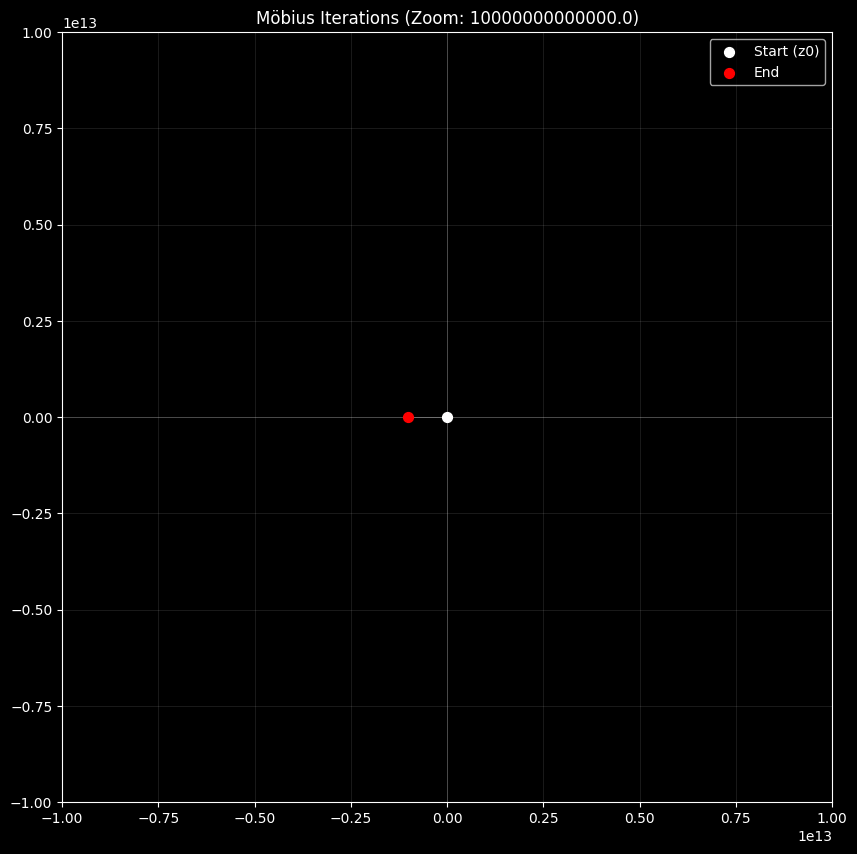

In [257]:
plot_sequence_dark(zn, 1e13)

In [258]:
i = 1
for z in zn:
    print(i, ':\t', z)
    i += 1

1 :	 0.99
2 :	 0.9897959183673467
3 :	 0.9895833333333331
4 :	 0.9893617021276595
5 :	 0.9891304347826084
6 :	 0.9888888888888886
7 :	 0.9886363636363634
8 :	 0.9883720930232557
9 :	 0.9880952380952378
10 :	 0.9878048780487803
11 :	 0.9874999999999999
12 :	 0.9871794871794872
13 :	 0.986842105263158
14 :	 0.9864864864864865
15 :	 0.9861111111111113
16 :	 0.985714285714286
17 :	 0.9852941176470593
18 :	 0.9848484848484854
19 :	 0.9843750000000007
20 :	 0.9838709677419359
21 :	 0.9833333333333338
22 :	 0.9827586206896557
23 :	 0.9821428571428577
24 :	 0.9814814814814821
25 :	 0.9807692307692316
26 :	 0.9800000000000008
27 :	 0.9791666666666674
28 :	 0.9782608695652182
29 :	 0.9772727272727282
30 :	 0.9761904761904769
31 :	 0.9750000000000006
32 :	 0.9736842105263166
33 :	 0.9722222222222229
34 :	 0.9705882352941185
35 :	 0.9687500000000009
36 :	 0.9666666666666677
37 :	 0.9642857142857154
38 :	 0.961538461538463
39 :	 0.958333333333335
40 :	 0.9545454545454568
41 :	 0.9500000000000027
42

Se puede ver con más zoom que las primeras iteraciones diverge

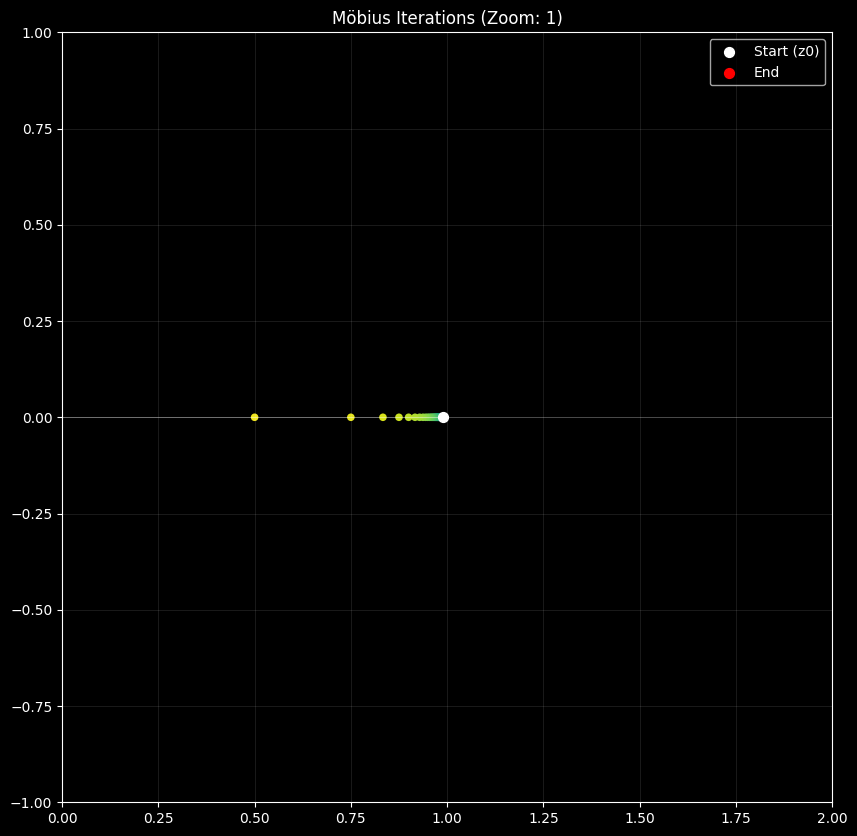

In [259]:
plot_sequence_dark(zn, 1)

## Comprobación de que eventualmente converge

Si cogemos suficientes iteraciones (de hecho después de irse al $-10^{12}$ vuelve al $1.5$), se ve como sigue convergiendo al 1 cómo hemos probado a mano)

In [260]:
# Transformation coefficients: (az + b) / (cz + d)
# These specific values often lead to interesting spiral behaviors
a, b = 3, -2
c, d = 2, -1

def R(z):
    return (a*z + b)/(c*z + d)

epsilon = -0.01
w = 1

z0 = 1+epsilon

max_iter = 100

zn = [z0]
for i in range(max_iter):
    next_z = R(zn[-1])
    zn.append(next_z)

Aquí se pueden ver las primeras iteraciones que van hacia la izquierda alejándose del 1, pero después vuelve por la derecha

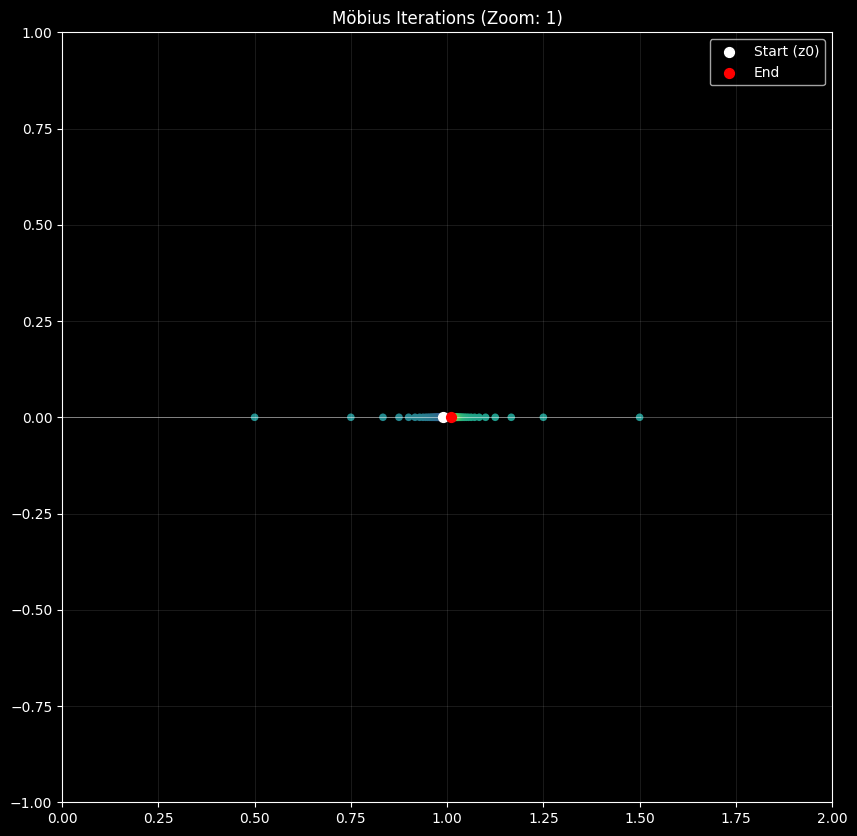

In [261]:
plot_sequence_dark(zn, 1)

In [262]:
i = 1
for z in zn:
    print(i, ':\t', z)
    i += 1

1 :	 0.99
2 :	 0.9897959183673467
3 :	 0.9895833333333331
4 :	 0.9893617021276595
5 :	 0.9891304347826084
6 :	 0.9888888888888886
7 :	 0.9886363636363634
8 :	 0.9883720930232557
9 :	 0.9880952380952378
10 :	 0.9878048780487803
11 :	 0.9874999999999999
12 :	 0.9871794871794872
13 :	 0.986842105263158
14 :	 0.9864864864864865
15 :	 0.9861111111111113
16 :	 0.985714285714286
17 :	 0.9852941176470593
18 :	 0.9848484848484854
19 :	 0.9843750000000007
20 :	 0.9838709677419359
21 :	 0.9833333333333338
22 :	 0.9827586206896557
23 :	 0.9821428571428577
24 :	 0.9814814814814821
25 :	 0.9807692307692316
26 :	 0.9800000000000008
27 :	 0.9791666666666674
28 :	 0.9782608695652182
29 :	 0.9772727272727282
30 :	 0.9761904761904769
31 :	 0.9750000000000006
32 :	 0.9736842105263166
33 :	 0.9722222222222229
34 :	 0.9705882352941185
35 :	 0.9687500000000009
36 :	 0.9666666666666677
37 :	 0.9642857142857154
38 :	 0.961538461538463
39 :	 0.958333333333335
40 :	 0.9545454545454568
41 :	 0.9500000000000027
42

## Generación de puntos iniciales cerca del 1 randoms para ver diferentes comportamientos

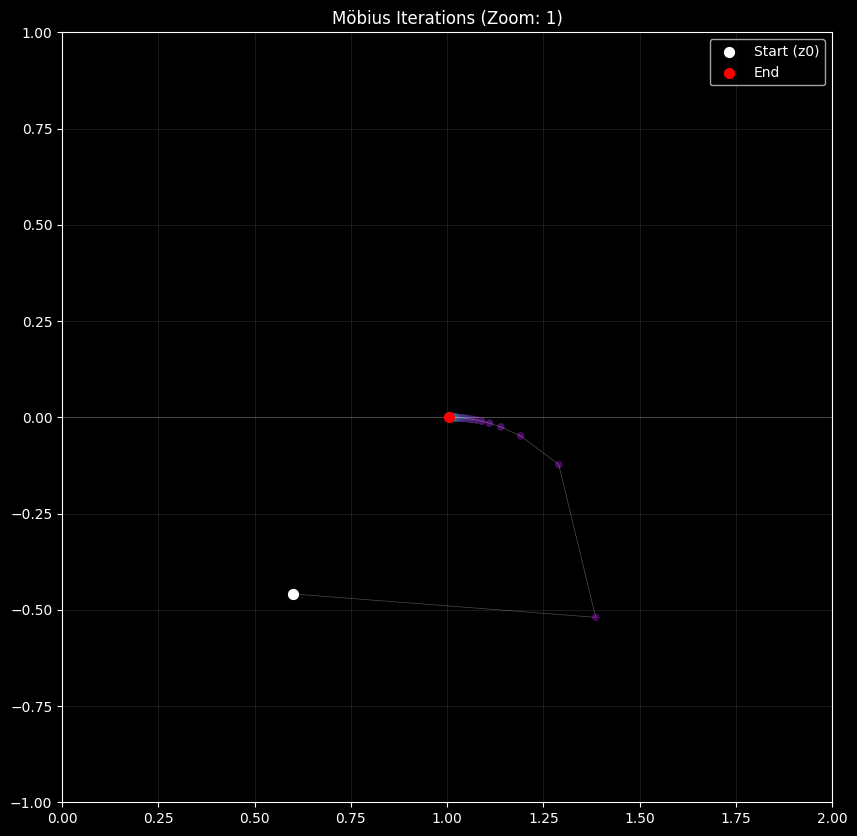

In [263]:
# Transformation coefficients: (az + b) / (cz + d)
# These specific values often lead to interesting spiral behaviors
a, b = 3, -2
c, d = 2, -1

def R(z):
    return (a*z + b)/(c*z + d)

radius = 0.5
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
w = 1

z0 = 1+r

max_iter = 100

zn = [z0]
for i in range(max_iter):
    next_z = R(zn[-1])
    zn.append(next_z)

plot_sequence_dark(zn, 1)